<a href="https://colab.research.google.com/github/TarigondaNareshReddy/DCGAN_GENAI/blob/main/MRI_Brain_Tumor_Classification_Hybrid_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile, os, random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from transformers import ViTForImageClassification
from PIL import Image

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

torch.manual_seed(42)


In [ ]:
zip_path = "/content/archive (6).zip"
extract_path = "/content/brain_tumor_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Ready!")


Dataset Ready!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3,[0.5]*3)
])


In [ ]:
dataset = datasets.ImageFolder(
    "/content/brain_tumor_dataset/Training",
    transform=transform
)

class_names = dataset.classes
print("Classes:", class_names)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [ ]:
cnn_model = models.resnet18(pretrained=True)
cnn_model.fc = nn.Linear(cnn_model.fc.in_features, 4)
cnn_model = cnn_model.to(device)

vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=4,
    ignore_mismatched_sizes=True
).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 222MB/s]
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your 

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
vit_model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=4,
    ignore_mismatched_sizes=True
).to(device)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=0.0001)
vit_optimizer = optim.Adam(vit_model.parameters(), lr=0.0001)

In [ ]:
def train_models():

    epochs = 10
    cnn_acc_list, vit_acc_list = [], []

    for epoch in range(epochs):

        cnn_model.train()
        vit_model.train()

        cnn_correct, vit_correct, total = 0, 0, 0

        for images, labels in train_loader:

            images, labels = images.to(device), labels.to(device)

            # CNN
            cnn_out = cnn_model(images)
            cnn_loss = criterion(cnn_out, labels)

            cnn_optimizer.zero_grad()
            cnn_loss.backward()
            cnn_optimizer.step()

            # ViT
            vit_out = vit_model(images).logits
            vit_loss = criterion(vit_out, labels)

            vit_optimizer.zero_grad()
            vit_loss.backward()
            vit_optimizer.step()

            _, cnn_pred = torch.max(cnn_out,1)
            _, vit_pred = torch.max(vit_out,1)

            cnn_correct += (cnn_pred == labels).sum().item()
            vit_correct += (vit_pred == labels).sum().item()

            total += labels.size(0)

        cnn_acc = cnn_correct / total
        vit_acc = vit_correct / total

        cnn_acc_list.append(cnn_acc)
        vit_acc_list.append(vit_acc)

        print(f"Epoch {epoch+1} | CNN: {cnn_acc:.4f} | ViT: {vit_acc:.4f}")

    return cnn_acc_list, vit_acc_list

cnn_acc, vit_acc = train_models()

Epoch 1 | CNN: 0.9074 | ViT: 0.8997
Epoch 2 | CNN: 0.9791 | ViT: 0.9824
Epoch 3 | CNN: 0.9890 | ViT: 0.9890
Epoch 4 | CNN: 0.9885 | ViT: 0.9908
Epoch 5 | CNN: 0.9949 | ViT: 0.9934
Epoch 6 | CNN: 0.9903 | ViT: 0.9929
Epoch 7 | CNN: 0.9957 | ViT: 0.9931
Epoch 8 | CNN: 0.9941 | ViT: 0.9952
Epoch 9 | CNN: 0.9972 | ViT: 0.9985
Epoch 10 | CNN: 0.9980 | ViT: 0.9980


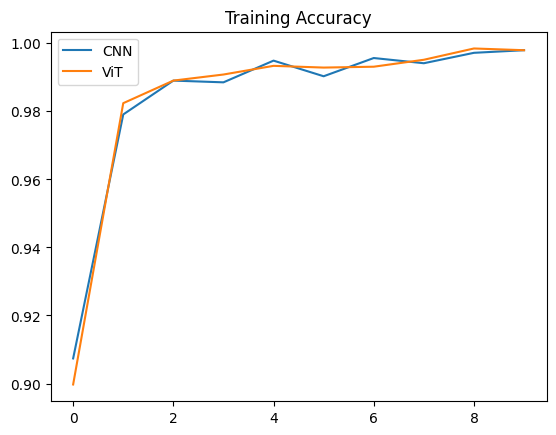

In [ ]:
plt.plot(cnn_acc, label="CNN")
plt.plot(vit_acc, label="ViT")
plt.legend()
plt.title("Training Accuracy")
plt.show()



CNN Accuracy: 0.9667063020214031
CNN F1: 0.9668971651465044


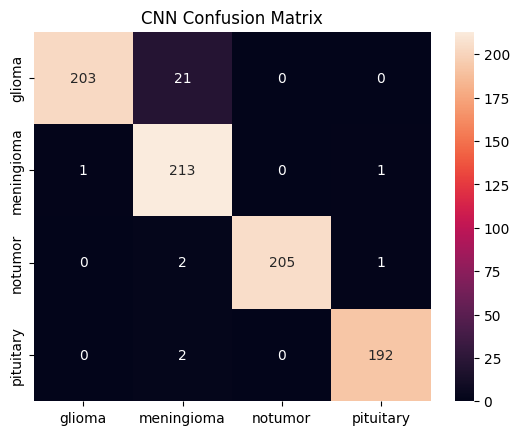


ViT Accuracy: 0.9785969084423306
ViT F1: 0.9783491522373114


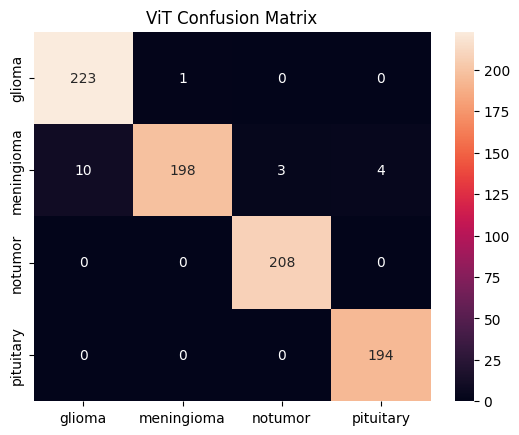

In [ ]:
def evaluate(model, name):

    model.eval()
    preds, labels_list = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            out = model(images)
            if "ViT" in str(type(model)):
                out = out.logits

            _, p = torch.max(out,1)

            preds.extend(p.cpu().numpy())
            labels_list.extend(labels.numpy())

    print(f"\n{name} Accuracy:", accuracy_score(labels_list, preds))
    print(f"{name} F1:", f1_score(labels_list, preds, average='weighted'))

    cm = confusion_matrix(labels_list, preds)

    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)
    plt.title(name + " Confusion Matrix")
    plt.show()

evaluate(cnn_model, "CNN")
evaluate(vit_model, "ViT")


In [ ]:
def grad_cam_fixed(model, image):

    model.eval()

    img = image.unsqueeze(0).to(device)
    img.requires_grad = True

    features = None

    def hook(module, input, output):
        nonlocal features
        features = output
        output.retain_grad()

    handle = model.layer3.register_forward_hook(hook)

    output = model(img)
    pred = output.argmax()

    model.zero_grad()
    output[0, pred].backward()

    gradients = features.grad

    weights = gradients.mean(dim=[2,3], keepdim=True)
    cam = (weights * features).sum(dim=1).squeeze()

    cam = torch.relu(cam)
    cam = cam.detach().cpu().numpy()

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    cam = cv2.resize(cam, (224,224))

    img_np = image.permute(1,2,0).cpu().numpy()
    img_np = (img_np * 0.5) + 0.5

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)/255

    overlay = 0.7 * heatmap + 0.3 * img_np

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(img_np)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(heatmap)
    plt.title("Heatmap")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(overlay)
    plt.title("Tumor Focus")
    plt.axis("off")

    plt.show()

    handle.remove()


True Label: meningioma


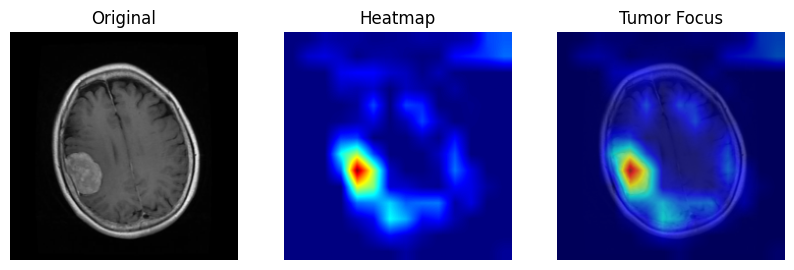

In [ ]:
img, label = test_dataset[random.randint(0,len(test_dataset)-1)]
print("True Label:", class_names[label])
grad_cam_fixed(cnn_model, img)

Prediction: notumor
Confidence: 0.9999474287033081


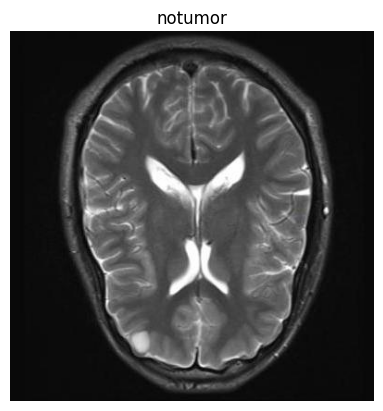

In [ ]:
def predict_image(path):
    image = Image.open(path).convert("RGB")
    img = transform(image).unsqueeze(0).to(device)
    cnn_model.eval()
    with torch.no_grad():
        out = cnn_model(img)
        probs = torch.softmax(out, dim=1)
        pred = torch.argmax(probs,1).item()
    print("Prediction:", class_names[pred])
    print("Confidence:", probs[0][pred].item())
    plt.imshow(image)
    plt.title(class_names[pred])
    plt.axis("off")
    plt.show()
# Predict MRI Image
predict_image("/content/Te-no_20.jpg")